In [1]:
import sys
from pathlib import Path
_r = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts' / 'config.py').exists())
sys.path.insert(0, str(_r / 'scripts'))
from notebook_init import setup
cfg, PATHS, POPULATIONS, HARD_FILTERS, SITUATIONAL_FILTERS, ML = setup()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations

# ── Faction 1: FST-Only ────────────────────────────────────────────────────
DIR_FST  = PATHS.ML_MODELS_FST        # fst/05b_fst_only_training

# ── Faction 2: Statistical V1 ─────────────────────────────────────────────
DIR_V1A  = PATHS.ML_MODELS_STAT       # statistical_v1/05a_stat_only_training
DIR_V1C  = PATHS.ML_MODELS_BOTH       # statistical_v1/05c_fst_and_stat_training

# ── Faction 3: Statistical V2 ─────────────────────────────────────────────
PREFIX_V2A = str(PATHS.outputs_dir("statistical_v2/05a_stat_training"))
PREFIX_V2B = str(PATHS.outputs_dir("statistical_v2/05b_reduction"))
DIR_V2C    = PATHS.outputs_dir("statistical_v2/05c_fst_stat_training")

# Faction colour palette (used throughout)
F_COLORS = {
    'fst':     '#f4a142',   # Faction 1
    'v1_stat': '#4e9af1',   # Faction 2a
    'v1_fst':  '#2563c4',   # Faction 2b
    'v2_stat': '#e64980',   # Faction 3a
    'v2_fst':  '#9b59b6',   # Faction 3b
}

def safe_load_top50(path, feature_col='feature', n=50):
    """Return top-n SNP IDs from a feature importance CSV, or empty set if missing."""
    p = Path(path)
    if not p.exists():
        print(f'  [missing] {p.name}')
        return set()
    df = pd.read_csv(p)
    col = feature_col if feature_col in df.columns else df.columns[0]
    return set(df[col].head(n).tolist())

print('Faction 1 — FST-only :', DIR_FST)
print('Faction 2 — V1 stat  :', DIR_V1A)
print('             V1 FST  :', DIR_V1C)
print('Faction 3 — V2 stat  :', PREFIX_V2A + '_*')
print('             V2 FST  :', DIR_V2C)

Project root : /home/ibmelab/Projects/AISNP_Research
genomes_data : /mnt/data/aisnp_data/1000genomes/
output root  : output
Faction 1 — FST-only : /mnt/data/aisnp_data/1000genomes/outputs/fst/05b_fst_only_training
Faction 2 — V1 stat  : /mnt/data/aisnp_data/1000genomes/outputs/statistical_v1/05a_stat_only_training
             V1 FST  : /mnt/data/aisnp_data/1000genomes/outputs/statistical_v1/05c_fst_and_stat_training
Faction 3 — V2 stat  : /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/05a_stat_training_*
             V2 FST  : /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/05c_fst_stat_training


## 1. Top-50 SNPs per Approach

In [2]:
print('Loading top-50 SNPs per sub-approach...')

# Faction 1
snps_fst = safe_load_top50(DIR_FST / 'feature_importances.csv')

# Faction 2
snps_v1a     = safe_load_top50(DIR_V1A / 'consensus_snps_importance.csv')
snps_v1c_rf  = safe_load_top50(DIR_V1C / 'rf_feature_importances.csv')
snps_v1c_lr  = safe_load_top50(DIR_V1C / 'lr_feature_importances.csv')

# Faction 3  (v2 05a uses 'snp_id' column, sorted best-first by avg_rank)
snps_v2a     = safe_load_top50(f"{PREFIX_V2A}_feature_importance.csv", feature_col='snp_id')
snps_v2c_rf  = safe_load_top50(DIR_V2C / 'rf_feature_importances.csv')

# Named dict used by all sections below
SETS = {
    'FST-only':   snps_fst,
    'V1 stat':    snps_v1a,
    'V1 FST+RF':  snps_v1c_rf,
    'V1 FST+LR':  snps_v1c_lr,
    'V2 stat':    snps_v2a,
    'V2 FST+RF':  snps_v2c_rf,
}
FACTION_OF = {
    'FST-only':  ('Faction 1\nFST-only',  F_COLORS['fst']),
    'V1 stat':   ('Faction 2\nStat V1',    F_COLORS['v1_stat']),
    'V1 FST+RF': ('Faction 2\nStat V1',    F_COLORS['v1_fst']),
    'V1 FST+LR': ('Faction 2\nStat V1',    F_COLORS['v1_fst']),
    'V2 stat':   ('Faction 3\nStat V2',    F_COLORS['v2_stat']),
    'V2 FST+RF': ('Faction 3\nStat V2',    F_COLORS['v2_fst']),
}

print()
for name, snps in SETS.items():
    status = f'{len(snps)} SNPs' if snps else '— not yet run'
    print(f'  {name:12s}: {status}')

available = {k: v for k, v in SETS.items() if v}

Loading top-50 SNPs per sub-approach...

  FST-only    : 50 SNPs
  V1 stat     : 50 SNPs
  V1 FST+RF   : 50 SNPs
  V1 FST+LR   : 50 SNPs
  V2 stat     : 50 SNPs
  V2 FST+RF   : 50 SNPs


## 2. Pairwise SNP Overlap

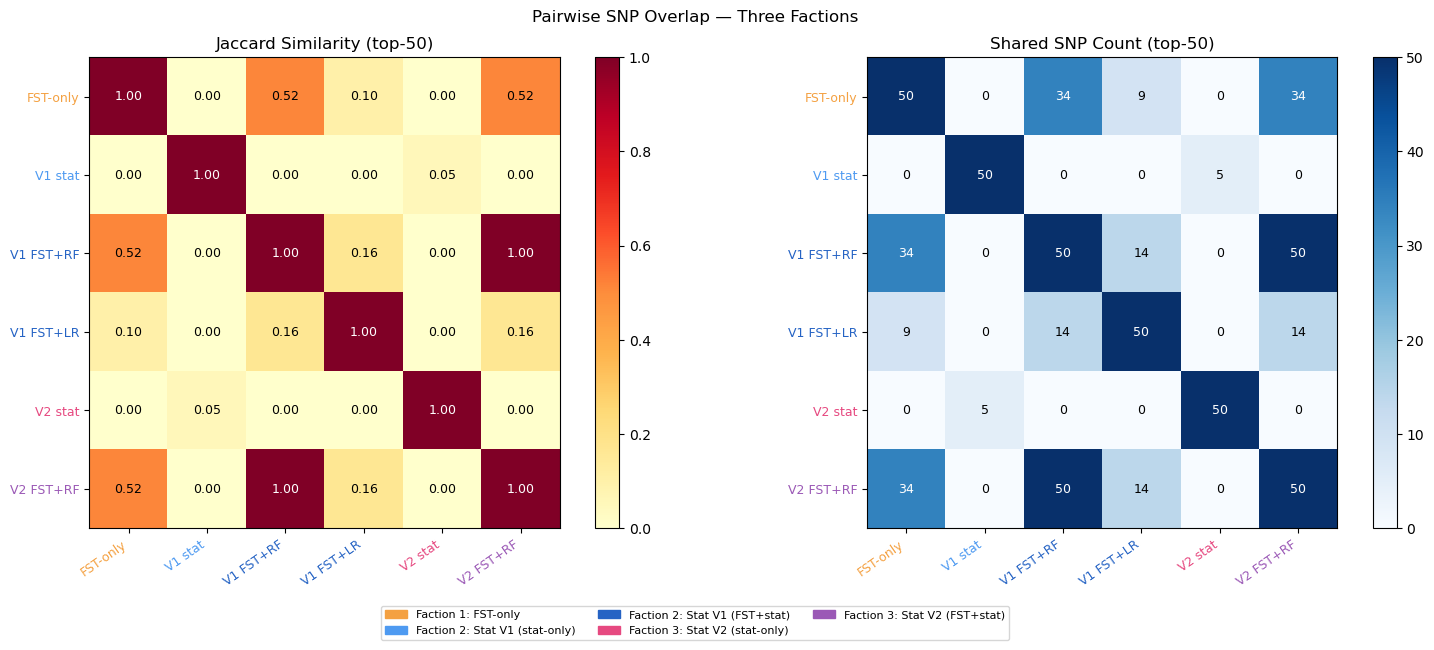

In [3]:
labels = list(available.keys())
n = len(labels)
jaccard = np.zeros((n, n))
overlap_count = np.zeros((n, n), dtype=int)
for i, (la, sa) in enumerate(available.items()):
    for j, (lb, sb) in enumerate(available.items()):
        inter = len(sa & sb)
        union = len(sa | sb)
        jaccard[i, j] = inter / union if union else 0
        overlap_count[i, j] = inter

bar_colors = [FACTION_OF[l][1] for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, mat, title, fmt, vmax in [
    (axes[0], jaccard,       'Jaccard Similarity (top-50)',  '.2f', 1.0),
    (axes[1], overlap_count, 'Shared SNP Count (top-50)',    'd',   50),
]:
    cmap = 'YlOrRd' if vmax == 1.0 else 'Blues'
    im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=vmax)
    ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=9)
    for i in range(n):
        for j in range(n):
            val = mat[i, j]
            text = f'{val:{fmt}}' if fmt != 'd' else str(int(val))
            ax.text(j, i, text, ha='center', va='center', fontsize=9,
                    color='white' if val > (vmax * 0.6) else 'black')
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    # Colour tick labels by faction
    for tick, lbl in zip(ax.get_xticklabels(), labels):
        tick.set_color(FACTION_OF[lbl][1])
    for tick, lbl in zip(ax.get_yticklabels(), labels):
        tick.set_color(FACTION_OF[lbl][1])

# Faction legend
patches = [
    mpatches.Patch(color=F_COLORS['fst'],     label='Faction 1: FST-only'),
    mpatches.Patch(color=F_COLORS['v1_stat'], label='Faction 2: Stat V1 (stat-only)'),
    mpatches.Patch(color=F_COLORS['v1_fst'],  label='Faction 2: Stat V1 (FST+stat)'),
    mpatches.Patch(color=F_COLORS['v2_stat'], label='Faction 3: Stat V2 (stat-only)'),
    mpatches.Patch(color=F_COLORS['v2_fst'],  label='Faction 3: Stat V2 (FST+stat)'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.08))
plt.suptitle('Pairwise SNP Overlap — Three Factions', fontsize=12)
plt.tight_layout()
plt.show()

## 3. SNP Set Membership

In [4]:
all_snps = set().union(*available.values())
rows = []
for snp in sorted(all_snps):
    row = {'snp_id': snp}
    for name, s in available.items():
        row[f'in_{name.replace(" ","_").replace("+","")}'] = snp in s
    rows.append(row)
membership = pd.DataFrame(rows)
in_cols = [c for c in membership.columns if c.startswith('in_')]
membership['n_approaches'] = membership[in_cols].sum(axis=1)

# Faction-level presence: present in ≥1 sub-approach of a faction
if snps_fst:
    membership['in_f1'] = membership['in_FST-only']
f2_cols = [c for c in in_cols if 'V1' in c]
f3_cols = [c for c in in_cols if 'V2' in c]
if f2_cols:
    membership['in_f2'] = membership[f2_cols].any(axis=1)
if f3_cols:
    membership['in_f3'] = membership[f3_cols].any(axis=1)

print('SNPs by number of sub-approaches they appear in:')
print(membership['n_approaches'].value_counts().sort_index().to_frame('count'))

faction_cols = [c for c in ['in_f1','in_f2','in_f3'] if c in membership.columns]
if len(faction_cols) >= 2:
    cross = membership[faction_cols].all(axis=1)
    print(f'\nSNPs appearing in ALL available factions: {cross.sum()}')
    if cross.sum():
        display(membership[cross][['snp_id'] + faction_cols].reset_index(drop=True))

SNPs by number of sub-approaches they appear in:
              count
n_approaches       
1               136
2                16
3                36
4                 6

SNPs appearing in ALL available factions: 34


,snp_id,in_f1,in_f2,in_f3
0,"10:134188783_b37_A,G",True,True,True
1,"10:7500776_b37_G,A",True,True,True
2,"11:112053732_b37_T,A",True,True,True
3,"12:4388084_b37_C,G",True,True,True
4,"14:106286458_b37_A,G",True,True,True
5,"14:96755874_b37_T,G",True,True,True
6,"14:96938945_b37_A,T",True,True,True
7,"16:33974960_b37_G,A",True,True,True
8,"16:49130020_b37_C,T",True,True,True
9,"16:67913222_b37_T,G",True,True,True


## 4. Unique vs Shared SNP Distribution

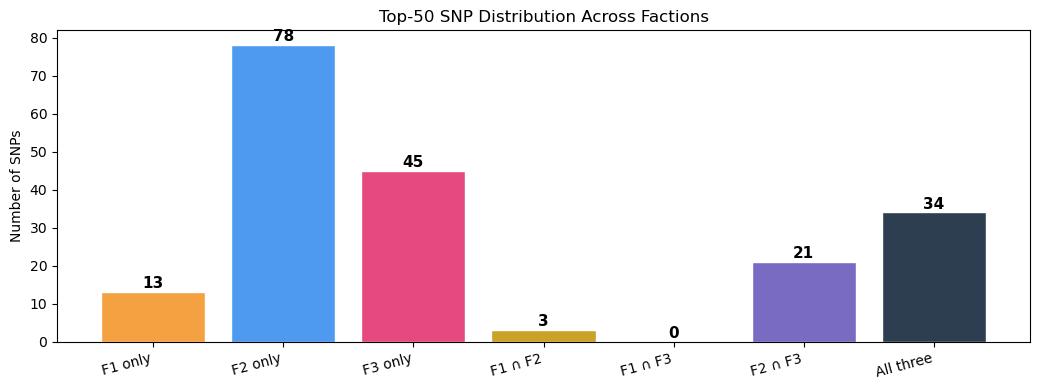

Total unique SNPs across all factions: 194


In [5]:
# Per-faction unique and cross-faction shared
def faction_set(keys):
    return set().union(*[available[k] for k in keys if k in available])

f1 = faction_set(['FST-only'])
f2 = faction_set(['V1 stat', 'V1 FST+RF', 'V1 FST+LR'])
f3 = faction_set(['V2 stat', 'V2 FST+RF'])

bars_data = []
if f1: bars_data.append(('F1 only',      len(f1 - f2 - f3),  F_COLORS['fst']))
if f2: bars_data.append(('F2 only',      len(f2 - f1 - f3),  F_COLORS['v1_stat']))
if f3: bars_data.append(('F3 only',      len(f3 - f1 - f2),  F_COLORS['v2_stat']))
if f1 and f2:
    bars_data.append(('F1 ∩ F2',    len(f1 & f2 - f3),   '#c9a227'))
if f1 and f3:
    bars_data.append(('F1 ∩ F3',    len(f1 & f3 - f2),   '#c07aad'))
if f2 and f3:
    bars_data.append(('F2 ∩ F3',    len(f2 & f3 - f1),   '#7a6bc2'))
if f1 and f2 and f3:
    bars_data.append(('All three',  len(f1 & f2 & f3),   '#2c3e50'))

labels_b  = [b[0] for b in bars_data]
counts_b  = [b[1] for b in bars_data]
colors_b  = [b[2] for b in bars_data]

fig, ax = plt.subplots(figsize=(max(8, len(bars_data) * 1.5), 4))
bars = ax.bar(labels_b, counts_b, color=colors_b, edgecolor='white')
for bar, cnt in zip(bars, counts_b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(cnt), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of SNPs')
ax.set_title('Top-50 SNP Distribution Across Factions')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(f'Total unique SNPs across all factions: {len(f1 | f2 | f3)}')

## 5. Performance Comparison

In [6]:
def safe_load_perf(path, approach_label, model_col=None, acc_col=None):
    p = Path(path)
    if not p.exists():
        print(f'  [missing] {p.name}')
        return pd.DataFrame()
    df = pd.read_csv(p)
    df.columns = [c.lower().replace(' ', '_') for c in df.columns]
    mc = model_col or next((c for c in df.columns if 'model' in c or 'classif' in c), df.columns[0])
    ac = acc_col   or next((c for c in df.columns if 'acc' in c), df.columns[1])
    return pd.DataFrame({'model': df[mc], 'accuracy': df[ac], 'approach': approach_label})

perf_parts = []

# Faction 1
p = safe_load_perf(DIR_FST / 'model_comparison.csv', 'F1: FST-only')
if not p.empty: perf_parts.append(p)

# Faction 2
p = safe_load_perf(DIR_V1A / 'consensus_snps_cv_results.csv', 'F2: V1 stat', acc_col='accuracy_mean')
if not p.empty: perf_parts.append(p)

p = safe_load_perf(DIR_V1C / 'statistical_ml_results.csv', 'F2: V1 FST+stat')
if not p.empty: perf_parts.append(p)

# Faction 3 — v2 05a: take union top-500 condition (best overall in that notebook)
v2a_all = Path(f"{PREFIX_V2A}_all_cv_results.csv")
if v2a_all.exists():
    df_v2a = pd.read_csv(v2a_all)
    # Best condition per classifier (max acc_mean across all conditions)
    best = df_v2a.groupby('classifier')['acc_mean'].max().reset_index()
    best.columns = ['model', 'accuracy']
    best['approach'] = 'F3: V2 stat'
    perf_parts.append(best)
else:
    print(f'  [missing] {v2a_all.name}')

p = safe_load_perf(DIR_V2C / 'statistical_ml_results.csv', 'F3: V2 FST+stat')
if not p.empty: perf_parts.append(p)

if perf_parts:
    combined_perf = pd.concat(perf_parts, ignore_index=True)
    print(f'Loaded {len(perf_parts)} performance tables  ({len(combined_perf)} rows)')
    for ap in combined_perf['approach'].unique():
        sub = combined_perf[combined_perf['approach'] == ap]
        print(f'  {ap}: best acc = {sub["accuracy"].max():.4f}  ({len(sub)} models)')
else:
    print('No performance data available yet.')
    combined_perf = pd.DataFrame()

Loaded 5 performance tables  (31 rows)
  F1: FST-only: best acc = 0.9484  (5 models)
  F2: V1 stat: best acc = 0.9028  (10 models)
  F2: V1 FST+stat: best acc = 0.9802  (3 models)
  F3: V2 stat: best acc = 0.9901  (10 models)
  F3: V2 FST+stat: best acc = 0.9802  (3 models)


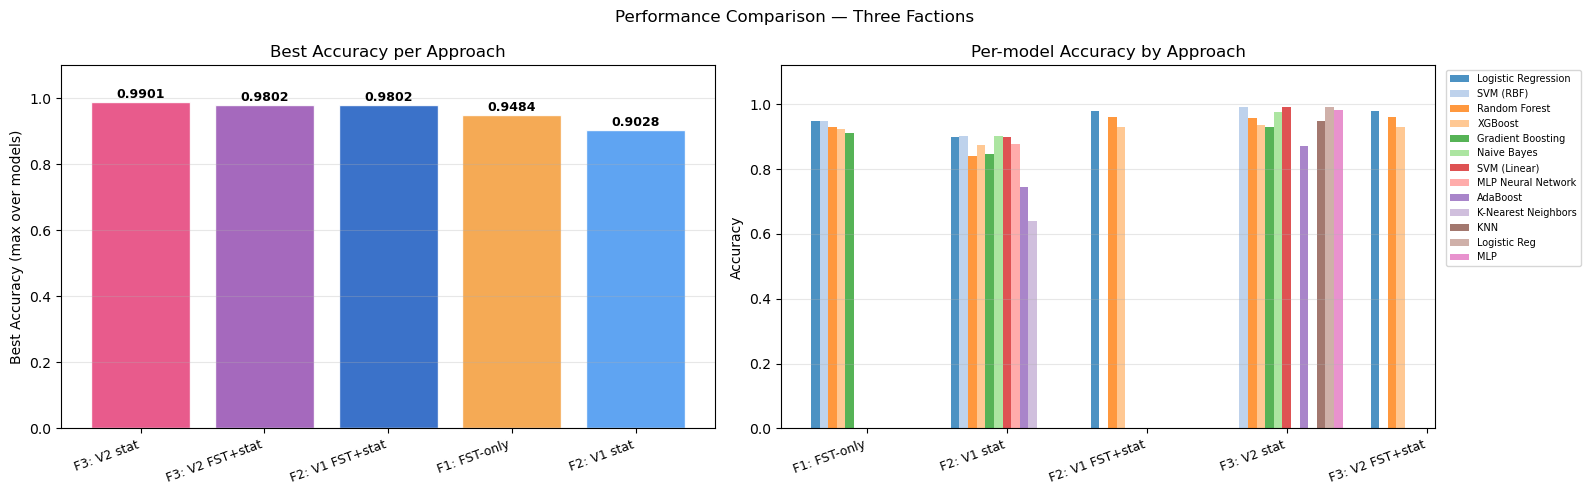

In [7]:
if combined_perf.empty:
    print('No performance data to plot.')
else:
    APPROACH_COLOR = {
        'F1: FST-only':     F_COLORS['fst'],
        'F2: V1 stat':      F_COLORS['v1_stat'],
        'F2: V1 FST+stat':  F_COLORS['v1_fst'],
        'F3: V2 stat':      F_COLORS['v2_stat'],
        'F3: V2 FST+stat':  F_COLORS['v2_fst'],
    }

    # Best accuracy per approach (max over models)
    best_per_ap = (combined_perf.groupby('approach')['accuracy']
                   .max().reset_index().sort_values('accuracy', ascending=False))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: best accuracy per approach
    ax = axes[0]
    colors_ap = [APPROACH_COLOR.get(ap, '#888') for ap in best_per_ap['approach']]
    bars = ax.bar(best_per_ap['approach'], best_per_ap['accuracy'],
                  color=colors_ap, edgecolor='white', alpha=0.9)
    for bar, v in zip(bars, best_per_ap['accuracy']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Best Accuracy (max over models)')
    ax.set_title('Best Accuracy per Approach')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Right: per-model grouped bar
    ax2 = axes[1]
    approaches = combined_perf['approach'].unique()
    models     = combined_perf['model'].unique()
    x = np.arange(len(approaches))
    width = 0.8 / max(len(models), 1)
    palette = plt.cm.tab20.colors

    for k, model in enumerate(models):
        vals = []
        for ap in approaches:
            sub = combined_perf[(combined_perf['approach'] == ap) & (combined_perf['model'] == model)]
            vals.append(sub['accuracy'].values[0] if len(sub) else np.nan)
        offset = (k - len(models) / 2 + 0.5) * width
        ax2.bar(x + offset, vals, width, label=model, color=palette[k % len(palette)], alpha=0.8)

    ax2.set_xticks(x)
    ax2.set_xticklabels(approaches, rotation=20, ha='right', fontsize=9)
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.12)
    ax2.set_title('Per-model Accuracy by Approach')
    ax2.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax2.grid(axis='y', alpha=0.3)

    plt.suptitle('Performance Comparison — Three Factions', fontsize=12)
    plt.tight_layout()
    plt.show()

## 6. Performance vs Feature Count

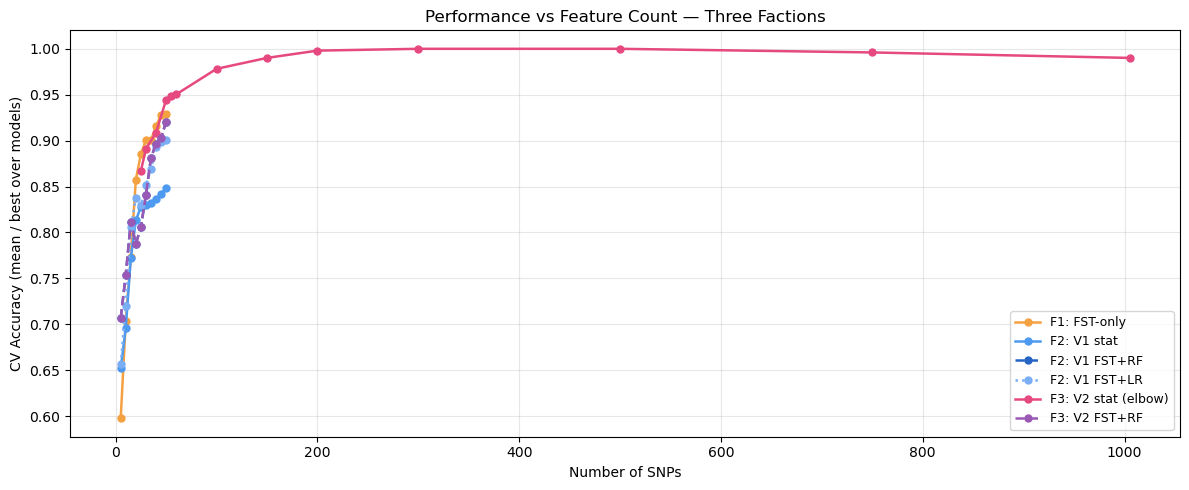

In [8]:
def safe_load_sweep(path, n_col_hint=None, acc_col_hint='acc'):
    p = Path(path)
    if not p.exists():
        print(f'  [missing] {Path(path).name}')
        return pd.DataFrame()
    df = pd.read_csv(p)
    df.columns = [c.lower() for c in df.columns]
    nc = n_col_hint or next((c for c in df.columns if 'snp' in c or 'panel' in c or 'n_' in c or 'feat' in c), df.columns[0])
    ac = next((c for c in df.columns if acc_col_hint in c), df.columns[1])
    return (df[[nc, ac]]
            .rename(columns={nc: 'n_snps', ac: 'accuracy'})
            .groupby('n_snps', as_index=False)
            .mean()
            .sort_values('n_snps'))

sweep_configs = [
    # (label, path, n_hint, color, linestyle)
    ('F1: FST-only',     DIR_FST  / 'feature_size_results.csv',    None,         F_COLORS['fst'],     '-'),
    ('F2: V1 stat',      DIR_V1A  / 'consensus_snps_reduced_results.csv', None,  F_COLORS['v1_stat'], '-'),
    ('F2: V1 FST+RF',    DIR_V1C  / 'rf_feature_size_results.csv', None,         F_COLORS['v1_fst'],  '--'),
    ('F2: V1 FST+LR',    DIR_V1C  / 'lr_feature_size_results.csv', None,         '#7aaef5',           ':'),
    # V2: 05b_reduction has the best panel-size sweep (best acc per panel_size)
    ('F3: V2 stat (elbow)', f"{PREFIX_V2B}_all_cv_results.csv",    'panel_size', F_COLORS['v2_stat'], '-'),
    ('F3: V2 FST+RF',    DIR_V2C  / 'rf_feature_size_results.csv', None,         F_COLORS['v2_fst'],  '--'),
]

fig, ax = plt.subplots(figsize=(12, 5))
plotted = 0
for label, path, n_hint, color, ls in sweep_configs:
    sw = safe_load_sweep(path, n_col_hint=n_hint)
    if sw.empty:
        continue
    # For v2 reduction: best acc per panel_size across classifiers
    if 'panel_size' in str(n_hint or ''):
        full = pd.read_csv(path)
        full.columns = [c.lower() for c in full.columns]
        sw = (full.groupby('panel_size')['acc_mean']
              .max().reset_index()
              .rename(columns={'panel_size': 'n_snps', 'acc_mean': 'accuracy'})
              .sort_values('n_snps'))
    ax.plot(sw['n_snps'], sw['accuracy'], marker='o', label=label,
            color=color, linestyle=ls, linewidth=1.8, markersize=5)
    plotted += 1

if plotted:
    ax.set_xlabel('Number of SNPs')
    ax.set_ylabel('CV Accuracy (mean / best over models)')
    ax.set_title('Performance vs Feature Count — Three Factions')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No sweep data available yet.')

## Summary

In [9]:
print('='*70)
print('SELF-EVALUATION SUMMARY — THREE FACTIONS')
print('='*70)

for name, snps in SETS.items():
    faction_lbl = FACTION_OF[name][0].replace('\n', ' ')
    print(f'  {name:14s} [{faction_lbl}]: {len(snps):3d} SNPs loaded')

print()
if f1 and f2:
    print(f'  F1 ∩ F2 (any sub-approach): {len(f1 & f2)}')
if f1 and f3:
    print(f'  F1 ∩ F3 (any sub-approach): {len(f1 & f3)}')
if f2 and f3:
    print(f'  F2 ∩ F3 (any sub-approach): {len(f2 & f3)}')
if f1 and f2 and f3:
    print(f'  All three factions         : {len(f1 & f2 & f3)}')

print()
if not combined_perf.empty:
    print('  Best accuracy per approach:')
    for _, row in best_per_ap.iterrows():
        print(f'    {row["approach"]:22s}: {row["accuracy"]:.4f}')

print('='*70)
if f3:
    print('\nFaction 3 (V2) is available — all three factions can be compared.')
else:
    print('\nFaction 3 (V2) not yet run. Execute 05a_stat_training and 05c_fst_stat_training')
    print('under statistical_v2/ to populate the comparison.')

SELF-EVALUATION SUMMARY — THREE FACTIONS
  FST-only       [Faction 1 FST-only]:  50 SNPs loaded
  V1 stat        [Faction 2 Stat V1]:  50 SNPs loaded
  V1 FST+RF      [Faction 2 Stat V1]:  50 SNPs loaded
  V1 FST+LR      [Faction 2 Stat V1]:  50 SNPs loaded
  V2 stat        [Faction 3 Stat V2]:  50 SNPs loaded
  V2 FST+RF      [Faction 3 Stat V2]:  50 SNPs loaded

  F1 ∩ F2 (any sub-approach): 37
  F1 ∩ F3 (any sub-approach): 34
  F2 ∩ F3 (any sub-approach): 55
  All three factions         : 34

  Best accuracy per approach:
    F3: V2 stat           : 0.9901
    F3: V2 FST+stat       : 0.9802
    F2: V1 FST+stat       : 0.9802
    F1: FST-only          : 0.9484
    F2: V1 stat           : 0.9028

Faction 3 (V2) is available — all three factions can be compared.
